Environment: velocity

In [1]:
import pyranges
import pandas
import scanpy
import hdf5plugin
import anndata
import cellrank
import matplotlib
from matplotlib import pyplot
import cellrank
import numpy
import gseapy
import pygam
import seaborn
import pydeseq2
import pydeseq2.dds
import pydeseq2.ds
import scipy
import decoupler
import scvelo

In [2]:
# Load data from Cellrank and SDEvelo

working_directory = "RNA Sequencing Data/"
base_name = "cellrank_version_5"
adata = scanpy.read_h5ad(
    working_directory+f"/{base_name}_anndata.h5ad"
)
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
combined_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_combined.csv",
    index_col=0
)

In [3]:
# Load adata with raw counts and filter

adata_raw = scanpy.read_h5ad(
    working_directory+f"/splice_counts_mm10.h5ad"
)

# Calculate proportion of mitochondrial genes
adata_raw.var["mt"] = adata_raw.var_names.str.startswith("mt-")
scanpy.pp.calculate_qc_metrics(
    adata_raw, qc_vars=["mt"], inplace=True, percent_top=[], log1p=False
)

scanpy.pp.calculate_qc_metrics(
    adata_raw, inplace=True, percent_top=[], log1p=False
)

# Filter cells by counts per cell, total counts and percent mitochondrial
included_cells = (adata_raw.obs["n_genes_by_counts"] >= 200)*(adata_raw.obs['total_counts'] <= 150000)*(adata_raw.obs['pct_counts_mt'] < 10)
adata_raw = adata_raw[included_cells]
print(adata_raw)

View of AnnData object with n_obs × n_vars = 12791 × 48526
    obs: 'barcode', 'batch', 'sample', 'group', 'day', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'ensemble_ids', 'gene_symbol', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors'
    obsm: 'X_fdl', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'


In [5]:
# Read ChIP-seq targets
base_name = "ChIP Sequencing Data/chipseq_targets"

hic2_target_scores = pandas.read_csv(f"{base_name}_hic2_scores.csv", index_col=0)
klf4_hic2_target_scores = pandas.read_csv(f"{base_name}_klf4_hic2_scores.csv", index_col=0)
klf4_control_target_scores = pandas.read_csv(f"{base_name}_klf4_control_scores.csv", index_col=0)

hic2_targets = numpy.loadtxt(f"{base_name}_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_hic2_targets = numpy.loadtxt(f"{base_name}_klf4_hic2_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_control_targets = numpy.loadtxt(f"{base_name}_klf4_control_targets.txt", dtype=numpy.dtypes.StrDType)
klf4_targets = numpy.intersect1d(klf4_hic2_targets, klf4_control_targets)
shared_targets = numpy.intersect1d(hic2_targets, klf4_targets)

In [6]:
# Load bulk differential expression results

bulk_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_combined.csv", index_col=0)
bulk_metadata = pandas.read_csv("RNA Sequencing Data/bulk_sequencing_metadata.csv", index_col=0)
samples = bulk_metadata.index.to_list()
reprogramming_columns = bulk_de.columns[bulk_de.columns.str.contains("Reprogramming")]
reprogramming_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_reprogramming.csv", index_col=0)
mef_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mef.csv", index_col=0)
mesc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_mesc.csv", index_col=0)
ipsc_de = pandas.read_csv("RNA Sequencing Data/bulk_differential_expression_ipsc.csv", index_col=0)

In [ ]:
# Function for plotting trends independent of trajectory

def plot_grouped_gene_trend(adata, genes, group_key="group", time_key="latent_time", layer="X", groups=None, columns=4, figure_width=14, plot_height=4, n_splines=6):
    """
    Plots smoothed gene expression using generalized additive models (GAMs).
    This provides true smooth local regression with confidence intervals.
    """

    number_of_genes = len(genes)
    number_of_columns = min(columns, number_of_genes)
    
    # Calculate rows
    rows = (number_of_genes + number_of_columns - 1) // number_of_columns
    
    figure, axes = pyplot.subplots(rows, number_of_columns)
    figure.set_figwidth(figure_width)
    figure.set_figheight(plot_height * rows)

    # Handle single gene case (axes is not an array) and 1D array case
    if number_of_genes == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    # Define colors for groups
    unique_groups = adata.obs[group_key].unique()
    if f"{group_key}_colors" in adata.uns_keys():
        palette = adata.uns[f"{group_key}_colors"]
        color_map = dict(zip(unique_groups, palette))
    else:
        palette = seaborn.color_palette("tab10", n_colors=len(unique_groups))
        color_map = dict(zip(unique_groups, palette))


    for gene_index, gene in enumerate(genes):
        axis = axes_flat[gene_index]
        
        # Fetch expression data
        if layer == "raw":
            expr_data = adata.raw.to_adata()[:, gene].X
        elif layer == "X":
            expr_data = adata[:, gene].X
        else:
            expr_data = adata[:, gene].layers[layer]
        if hasattr(expr_data, "toarray"):
            expr_data = expr_data.toarray()
        expr_data = expr_data.flatten()
        
        # Create DataFrame
        df = pandas.DataFrame({
            "Latent Time": adata.obs[time_key],
            "Expression": expr_data,
            "Group": adata.obs[group_key]
        })
        
        # Determine which groups to plot
        if groups is None:
            # If no specific list, plot all groups found in the data
            plot_groups = df["Group"].unique()
        else:
            plot_groups = groups

        # Loop through each group and fit a GAM
        for group in plot_groups:
            group_data = df[df["Group"] == group]
            color = color_map[group]
            
            # Skip empty groups
            if len(group_data) < 10:
                continue

            # Prepare X and y for pygam
            X = group_data["Latent Time"].values.reshape(-1, 1)
            y = group_data["Expression"].values
            
            # Fit LinearGAM using a spline term s(0)
            gam = pygam.LinearGAM(pygam.s(0, n_splines=n_splines)).fit(X, y)
            
            # Greate grid
            X_grid = numpy.linspace(X.min(), X.max(), 500)
            
            # Predict values and confidence intervals
            y_pred = gam.predict(X_grid)
            confidence_intervals = gam.confidence_intervals(X_grid, width=0.95)
            
            # Plot line
            axis.plot(X_grid, y_pred, label=group, color=color, linewidth=3)
            
            # Plot confidence interval
            axis.fill_between(
                X_grid, 
                confidence_intervals[:, 0], 
                confidence_intervals[:, 1], 
                color=color, 
                alpha=0.2
            )

        axis.set_title(f"{gene} expression")
        axis.set_xlabel("Latent Time")
        
        # Add legend to the first plot
        if gene_index == 0:
            axis.legend()

    # Clean up empty subplots
    for i in range(number_of_genes, len(axes_flat)):
        axes_flat[i].axis('off')

    pyplot.tight_layout()
    pyplot.show()

# Define colors for all three groups

group_colors = [
    "#cbc9ca",
    "#0a652c",
    "#da2e24",
    "#3180bd",
]

adata.uns["group_colors"] = group_colors

control_indices = adata.obs["group"] == "control"
hic2_indices = adata.obs["group"] == "Hic2"
reprogramming_group_indices = (adata.obs["group"] == "control") | (adata.obs["group"] == "Hic2")

# Identify ChipSeq targets of Hic2

In [69]:
# Variable genes and Cellrank drivers
variable_genes = adata.var_names.to_numpy()
variable_in_bulk = numpy.intersect1d(variable_genes, bulk_de.index.to_numpy())
stem_cell_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=True).head(100).index.to_numpy()
dead_end_drivers = driver_df.sort_values("Day 12 Control_corr", ascending=False).head(100).index.to_numpy()

In [70]:
# Load list of transcription factors

tf_df = pandas.read_csv("ChIP Sequencing Data/Mus_musculus_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_numpy()

In [71]:
differentially_expressed_genes = reprogramming_de.loc[variable_in_bulk].query("padj < 0.05").index.to_numpy()

In [72]:
# Find Hic2 target TFs that change significantly during reprogramming

# All target transcription factors
target_tfs = numpy.intersect1d(shared_targets, tf_array)

# Target transcription factors for which Hic2 changes expression significantly
de_target_tfs = numpy.intersect1d(target_tfs, differentially_expressed_genes)

In [73]:
# Differentially expressed targets that are drivers of dead end

de_dead_end_drivers = numpy.intersect1d(de_target_tfs, dead_end_drivers)
reprogramming_de.loc[de_dead_end_drivers].sort_values("log2FoldChange")

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Tlx2,585.037236,-1.107785,0.157145,-7.049422,1.796624e-12,2.177406e-11
Zbtb7c,1521.129230,-0.943320,0.058151,-16.221943,3.528526e-59,8.875744e-57


All dead end driver TFs that are targets of Hic2 are differentially expressed. Tlx2 is an interesting targets that have not been linked to reprogramming efficiency before. It is a clearer reprogramming driver in Hic2 OX than in control. Hoxa7 and Hmgb3 do not look like drivers in the Cellrank plot. Zbtb7 only looks like a driver in Hic2, and it has much higher expression in Hic2.

In [74]:
hic2_target_scores.loc["Dmrtc2"]

chip_score    0.775534
Name: Dmrtc2, dtype: float64

Dmtrc2 is not a Klf4 target, making it less consistent with the overall hypothesis. Cdh1 is not a Klf4 target.

In [75]:
# Differentially expressed targets that are drivers of stem cells

de_stem_cell_drivers = numpy.intersect1d(de_target_tfs, stem_cell_drivers)
reprogramming_de.loc[de_stem_cell_drivers].sort_values("log2FoldChange", ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Zfp42,2688.373406,1.344900,0.149763,8.980156,2.703821e-19,6.666513e-18
Tcf7l1,582.207950,1.263931,0.164272,7.694150,1.424378e-14,2.177080e-13
Jarid2,2140.717811,0.820343,0.135571,6.051022,1.439299e-09,1.214135e-08
Rest,2085.826504,0.492894,0.113039,4.360393,1.298291e-05,6.121253e-05


All stem cell driver TFs that are targets of Hic2 except Klf2, Mycn and Tsc22d1 have differential expression.

In [76]:
# All of them are also targets of Klf4
numpy.intersect1d(de_stem_cell_drivers, klf4_targets)

array(['Jarid2', 'Rest', 'Tcf7l1', 'Zfp42'], dtype=object)

Other factors to consider:
- Better Cellrank analysis, such as correlation with states early in trajectory, or at least ignoring very late latent times to ignore what happens when cells become stem cells.
- Differential expression in important parts of the trajectory, such as the Day 4 Control macrostate.
- Enrichment of motifs among differentially expressed genes. 
- Public ChipSeq data
- Public perturbation followed by expression data

# Activity of transcription factor targets

In [77]:
# Investigate how Hic2 affects Klf4 expression

reduced_columns = ["Reprogramming LFC", "Reprogramming p adjusted", "MEF LFC", "MEF p adjusted", "mESC LFC", "mESC p adjusted",
                   "iPSC LFC", "iPSC p adjusted"]
bulk_de.loc["Klf4", reduced_columns]

Reprogramming LFC          -2.592896e-02
Reprogramming p adjusted    8.158653e-01
MEF LFC                    -8.392690e-01
MEF p adjusted              2.611282e-03
mESC LFC                    1.706289e+00
mESC p adjusted             3.082652e-24
iPSC LFC                   -4.795948e-01
iPSC p adjusted             9.998311e-01
Name: Klf4, dtype: float64

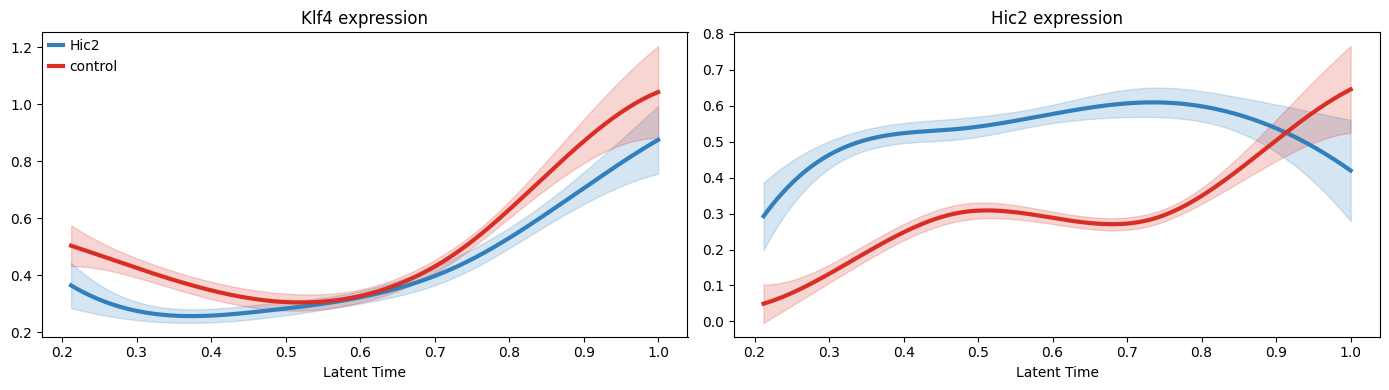

In [125]:
plot_grouped_gene_trend(adata, genes=["Klf4", "Hic2"], groups=["Hic2", "control"])

Hic2 OX decreased Klf4 expression in MEFs, but Hic2 KO decreased Klf4 expression in mESCs. Inconclusive, but since Hic2 is mainly a repressor a direct effect would probably be downregulation. The grouped trend plot suggests Klf4 is downregulated slightly by Hic2.

CollecTRI appears to be a useful database. Dorothea lacks many TFs such as Ovol1, Tlx2 and Hoxa7.

In [78]:
# Load CollecTRI database

collectri_df = decoupler.op.collectri(organism="mouse")

In [79]:
# Targets of Myc

genes_of_interest = de_dead_end_drivers.tolist() + de_stem_cell_drivers.tolist() + ["Klf4", "Hic2"]
collectri_df.query("source == \"Myc\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
11396,Myc,Ovol1,1.0,ExTRI,16636146,default activation
14303,Myc,Klf4,1.0,ExTRI,19736564,default activation


In [80]:
# Genes affecting Myc

collectri_df.query("target == \"Myc\" and source in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
14302,Klf4,Myc,1.0,ExTRI;NTNU.Curated,17974960,default activation


In [81]:
# Targets of Sox2

genes_of_interest = de_dead_end_drivers.tolist() + de_stem_cell_drivers.tolist() + ["Klf4", "Hic2"]
collectri_df.query("source == \"Sox2\" and target in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
11552,Sox2,Zfp42,1.0,ExTRI;NTNU.Curated,16714766,regulon


In [82]:
# Genes affecting Sox2

collectri_df.query("target == \"Sox2\" and source in @genes_of_interest")

,source,target,weight,resources,references,sign_decision
39727,Klf4,Sox2,1.0,GEREDB,20689077,default activation


In [83]:
collectri_df.query("source == \"Myc\" and target == \"Klf4\"")

,source,target,weight,resources,references,sign_decision
14303,Myc,Klf4,1.0,ExTRI,19736564,default activation


In [84]:
# Check how Klf4 affects its own expression

collectri_df.query("source == \"Klf4\" and target == \"Klf4\"")

,source,target,weight,resources,references,sign_decision
4817,Klf4,Klf4,1.0,ExTRI;NTNU.Curated,12087155;22337869;22854048,PMID


In [85]:
# Other targets of Klf4

collectri_df.query("source == \"Klf4\"").head(30)

,source,target,weight,resources,references,sign_decision
1675,Klf4,Cdkn1a,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;TRRUST,10749849;18483411;18645021;19737957;21132436;2...,PMID
1848,Klf4,Krt4,1.0,ExTRI;GEREDB;NTNU.Curated,10802067;14647409,PMID
2249,Klf4,Actg2,-1.0,ExTRI;NTNU.Curated,10954723;16858008,PMID
3616,Klf4,Cdx2,1.0,TRRUST,23202735,default activation
3661,Klf4,Lama3,1.0,ExTRI;GEREDB;NTNU.Curated;TRRUST,11551969,PMID
4692,Klf4,Lamc1,1.0,ExTRI;NTNU.Curated,12034813,PMID
4813,Klf4,Id3,-1.0,ExTRI;GEREDB;NTNU.Curated,12087069;19618124,PMID
4817,Klf4,Klf4,1.0,ExTRI;NTNU.Curated,12087155;22337869;22854048,PMID
5048,Klf4,Gstp2,-1.0,ExTRI;GEREDB;NTNU.Curated,12186428,PMID
5049,Klf4,Gstp1,-1.0,ExTRI;GEREDB;NTNU.Curated,12186428,PMID


In [86]:
# Check Ovol1 targets

collectri_df.query("source == \"Ovol1\"")

,source,target,weight,resources,references,sign_decision
9262,Ovol1,Id2,1.0,ExTRI,15716349,default activation
11395,Ovol1,Myc,-1.0,ExTRI;NTNU.Curated,16636146,PMID
11924,Ovol1,Gadd45a,1.0,ExTRI,16908841,default activation
11925,Ovol1,Gadd45b,1.0,ExTRI,16908841,default activation
11926,Ovol1,Lemd3,1.0,ExTRI,16908841,default activation
11927,Ovol1,Sgk1,1.0,ExTRI,16908841,default activation
12197,Ovol1,Ovol2,-1.0,ExTRI;NTNU.Curated,17049212,PMID
12910,Ovol1,Ovol1,-1.0,ExTRI;GOA,17311813,PMID
14851,Ovol1,Chuk,1.0,ExTRI,18268325,default activation
19305,Ovol1,Cdh2,1.0,ExTRI,20463035,default activation


In [87]:
ovol1_targets = collectri_df.query("source == \"Ovol1\"")["target"].to_numpy()
reprogramming_de.loc[ovol1_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Id2,1669.476516,0.709558,0.162943,4.354635,1.332890e-05,6.273125e-05
Myc,18952.909643,-0.137470,0.083679,-1.642833,1.004176e-01,1.902238e-01
Gadd45a,381.938162,0.402600,0.109673,3.670918,2.416812e-04,9.070717e-04
Gadd45b,716.061569,0.407813,0.208509,1.955855,5.048224e-02,1.075557e-01
Lemd3,1320.406975,0.078918,0.044580,1.770268,7.668243e-02,1.524301e-01
Sgk1,507.045197,-0.575744,0.169050,-3.405763,6.597939e-04,2.276496e-03
Ovol2,47.086576,-0.377526,0.246902,-1.529050,1.262522e-01,2.287359e-01
Ovol1,680.945017,-1.451013,0.185601,-7.817914,5.370601e-15,8.644510e-14
Chuk,2215.038586,0.308015,0.067620,4.555098,5.236122e-06,2.647169e-05
Cdh2,2414.041323,0.392772,0.135501,2.898654,3.747684e-03,1.099156e-02


Ovol1 is downregulated by Hic2, meaning targets with weight 1 should be downregulated and weight -1 upregulated. Looking at Ovol1 targets suggest the reverse, that Ovol1 activity is increased.

In [25]:
combined_driver_df.loc[numpy.intersect1d(ovol1_targets, combined_driver_df.index)]

,Full correlation,Early correlation,Late correlation,Control correlation,Hic2 correlation
gene_names,,,,,
Gadd45a,0.107339,0.169306,0.137596,0.041132,0.122508
Gadd45b,0.349400,0.364824,0.075570,0.196689,0.126894
Id2,0.122064,0.136645,0.006509,0.097775,-0.070096
Myc,-0.350729,-0.208416,-0.562034,-0.311913,-0.257370
Ovol1,-0.445423,-0.387631,-0.508904,-0.365192,-0.098530
Sgk1,0.228076,0.094151,0.496773,0.336655,0.174854


In [26]:
tlx2_targets = collectri_df.query("source == \"Tlx2\"")["target"].to_numpy()
reprogramming_de.loc[tlx2_targets]

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ret,23.091996,-0.732177,0.280192,-2.613130,0.008972,0.024003
Slc8a3,10.349976,-0.587062,0.502865,-1.167435,0.243035,0.382619
Phox2b,24.553547,0.657880,0.440967,1.491903,0.135725,0.242223
Phox2a,183.685399,-0.313819,0.079289,-3.957924,0.000076,0.000312
Anxa5,7650.349077,-0.373951,0.105238,-3.553380,0.000380,0.001373


In [27]:
collectri_df.query("source == \"Zbtb7c\"")

,source,target,weight,resources,references,sign_decision
22846,Zbtb7c,Cdkn1a,-1.0,ExTRI;NTNU.Curated,22253232,PMID
23002,Zbtb7c,Fasn,1.0,ExTRI;NTNU.Curated,22331133,PMID


In [88]:
# Estimate activities of TF targets

data = reprogramming_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

In [89]:
dead_end_drivers_with_activities = numpy.intersect1d(de_dead_end_drivers, activities_df.index).tolist()
stem_cell_drivers_with_activities = numpy.intersect1d(de_stem_cell_drivers, activities_df.index).tolist()

In [90]:
# Activities of dead end drivers

activities_df.loc[dead_end_drivers_with_activities]

,Activity,Adjusted p-value
Ovol1,2.635745,0.053613
Tlx2,-1.347002,0.391778


In [91]:
# Activities of stem cell drivers

activities_df.loc[stem_cell_drivers_with_activities]

,Activity,Adjusted p-value
Jarid2,-0.206559,0.911306
Rest,1.306793,0.411599
Tcf7l1,-0.343872,0.852213
Zfp42,2.184417,0.121129


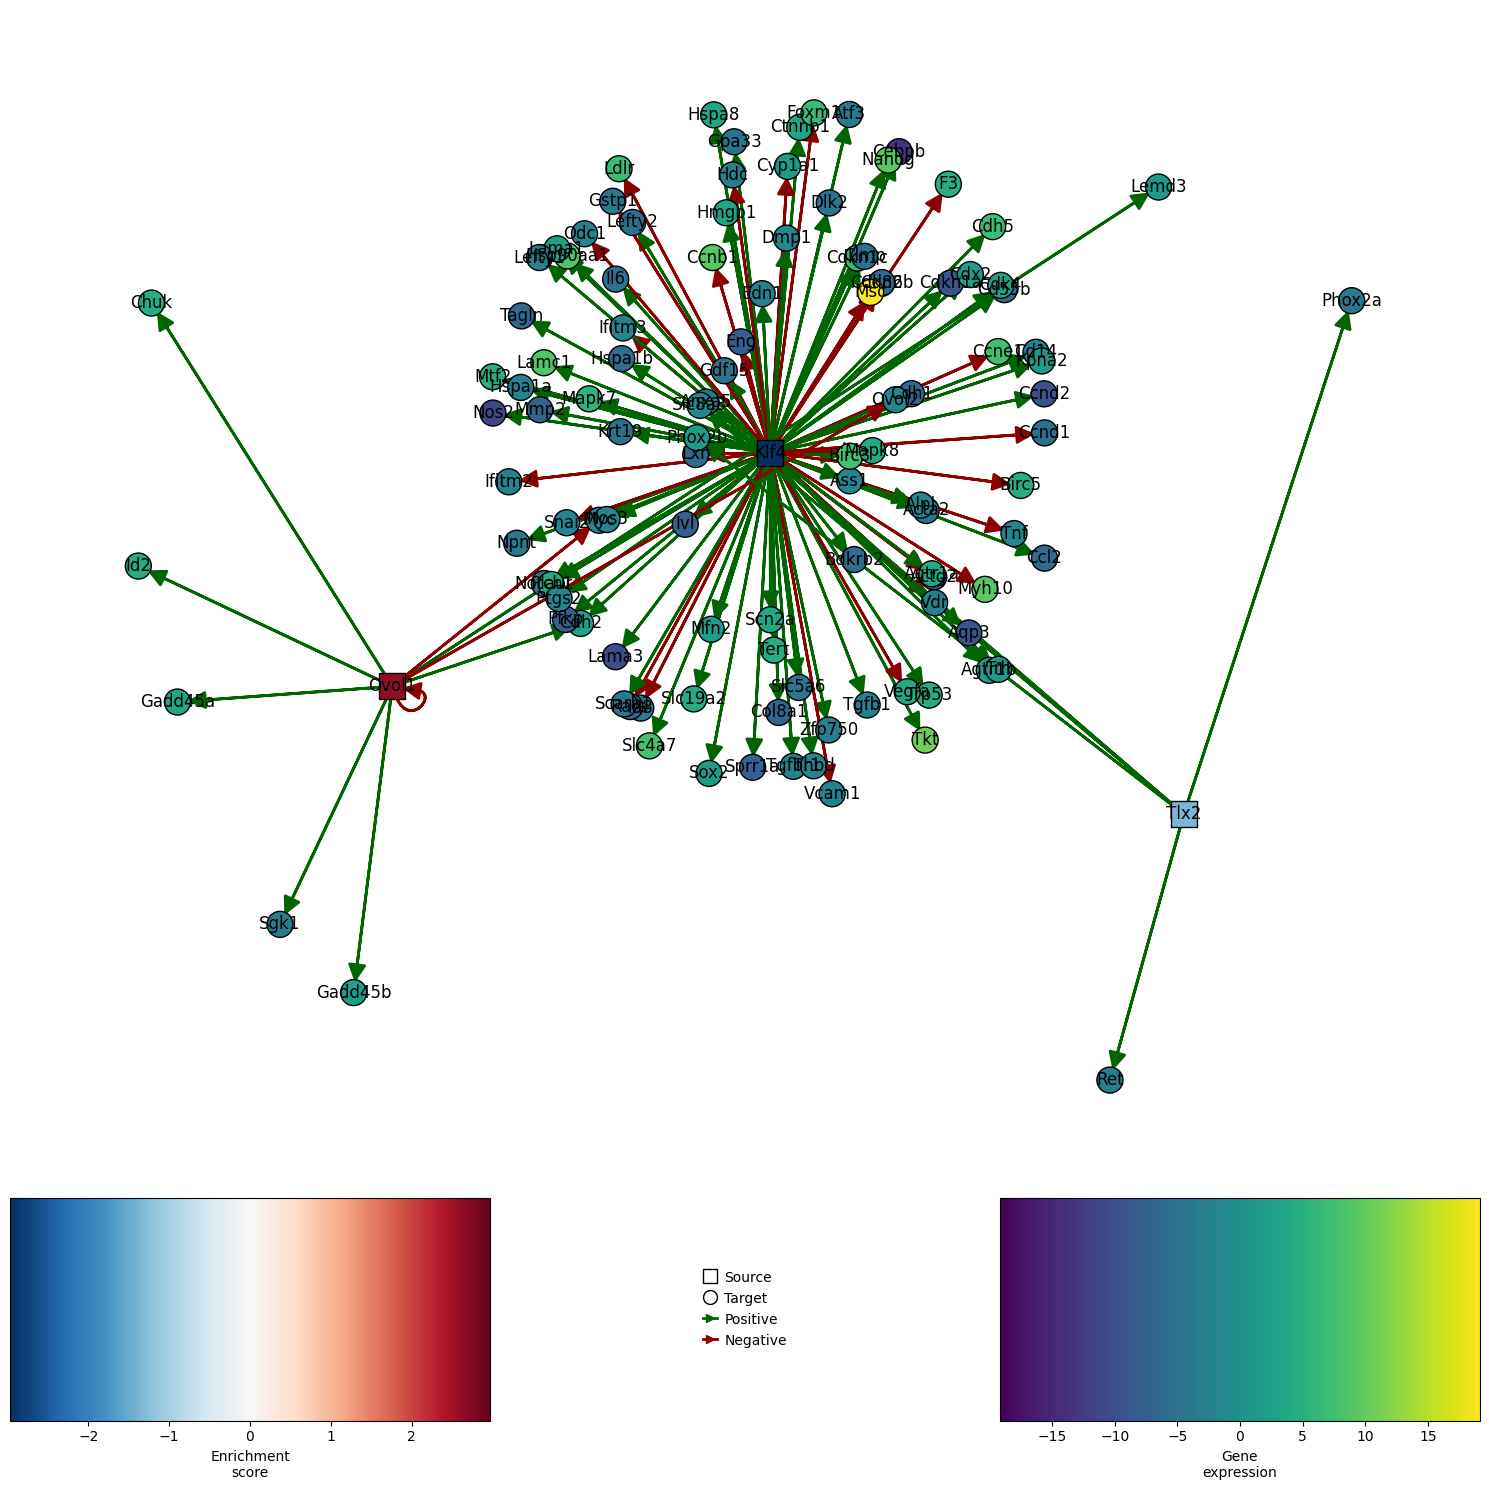

In [92]:
# Plot dead end network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

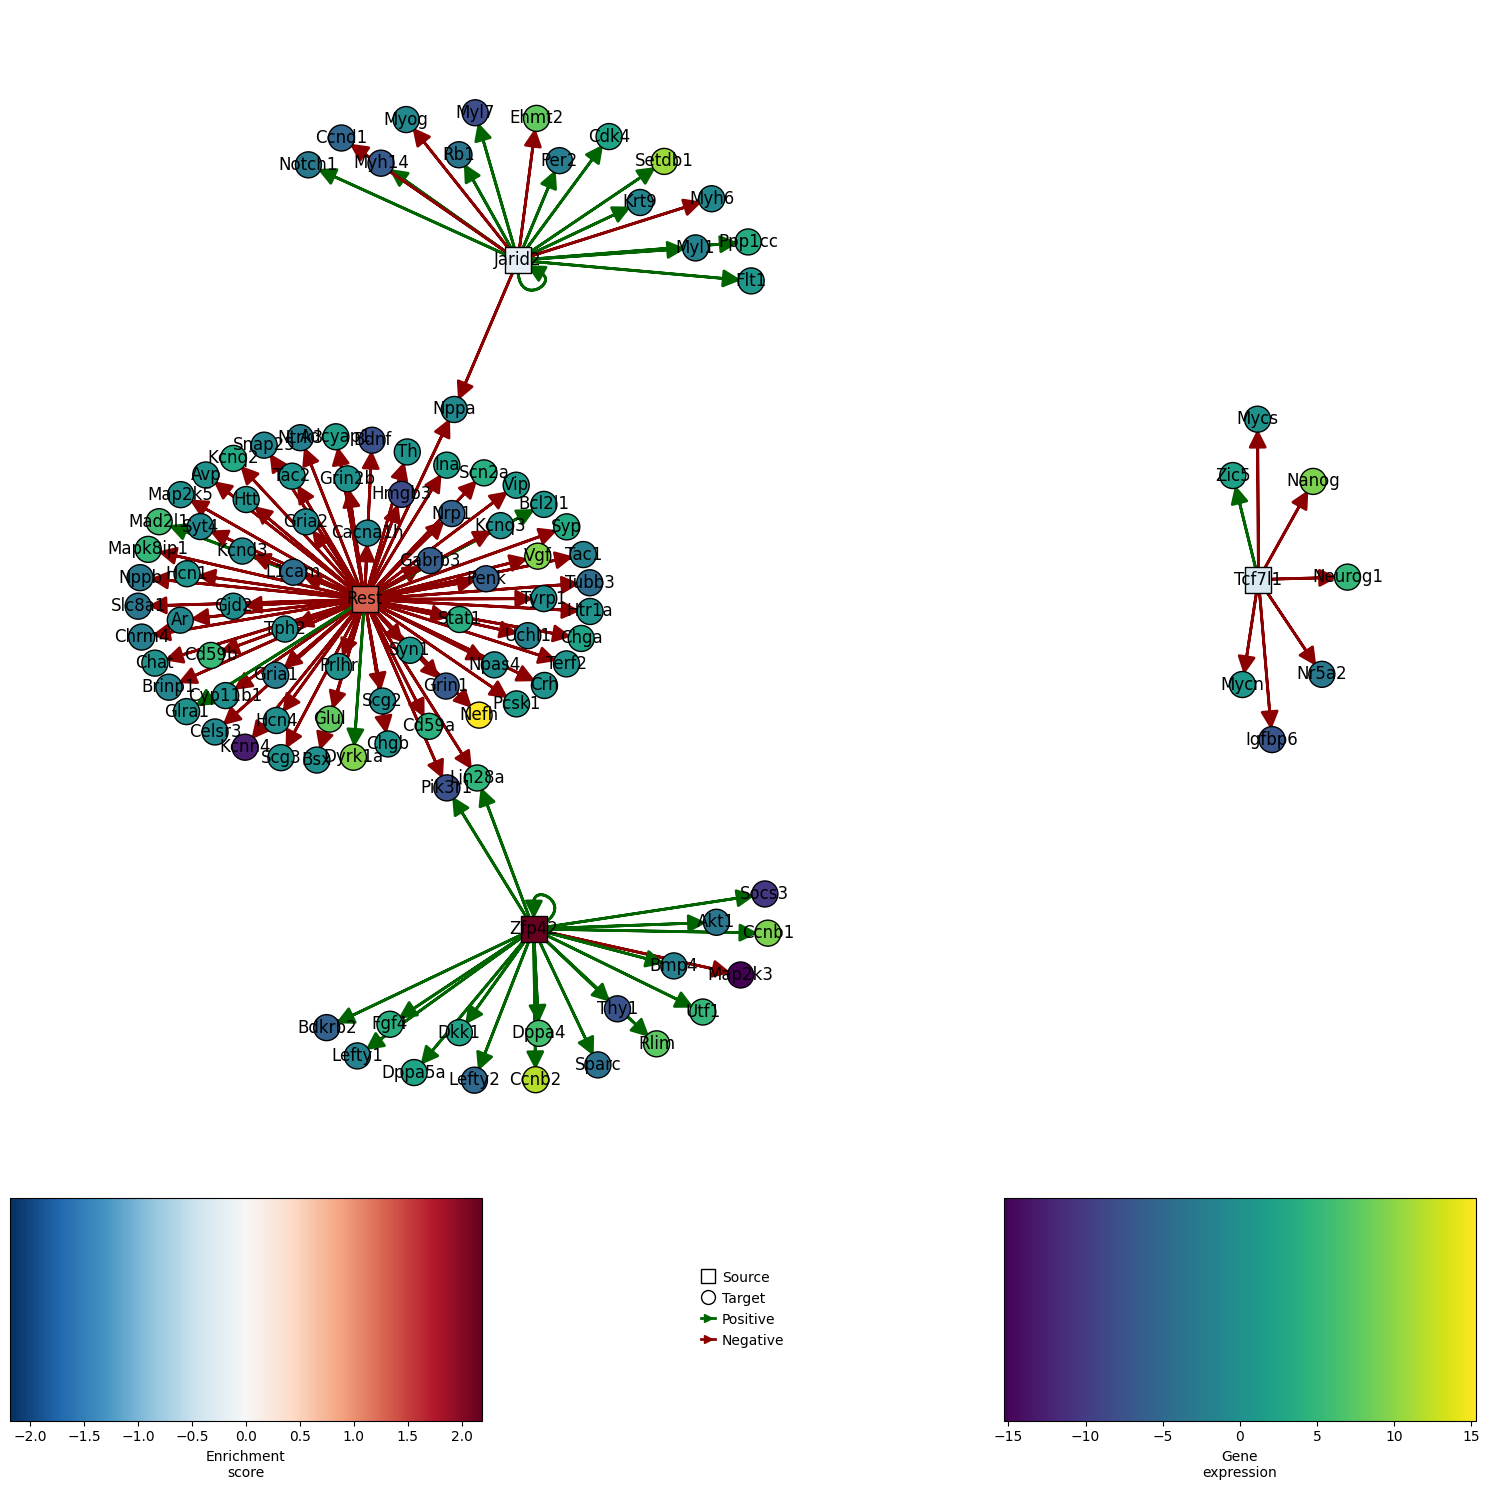

In [93]:
# Plot reprogramming network

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=stem_cell_drivers_with_activities,
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

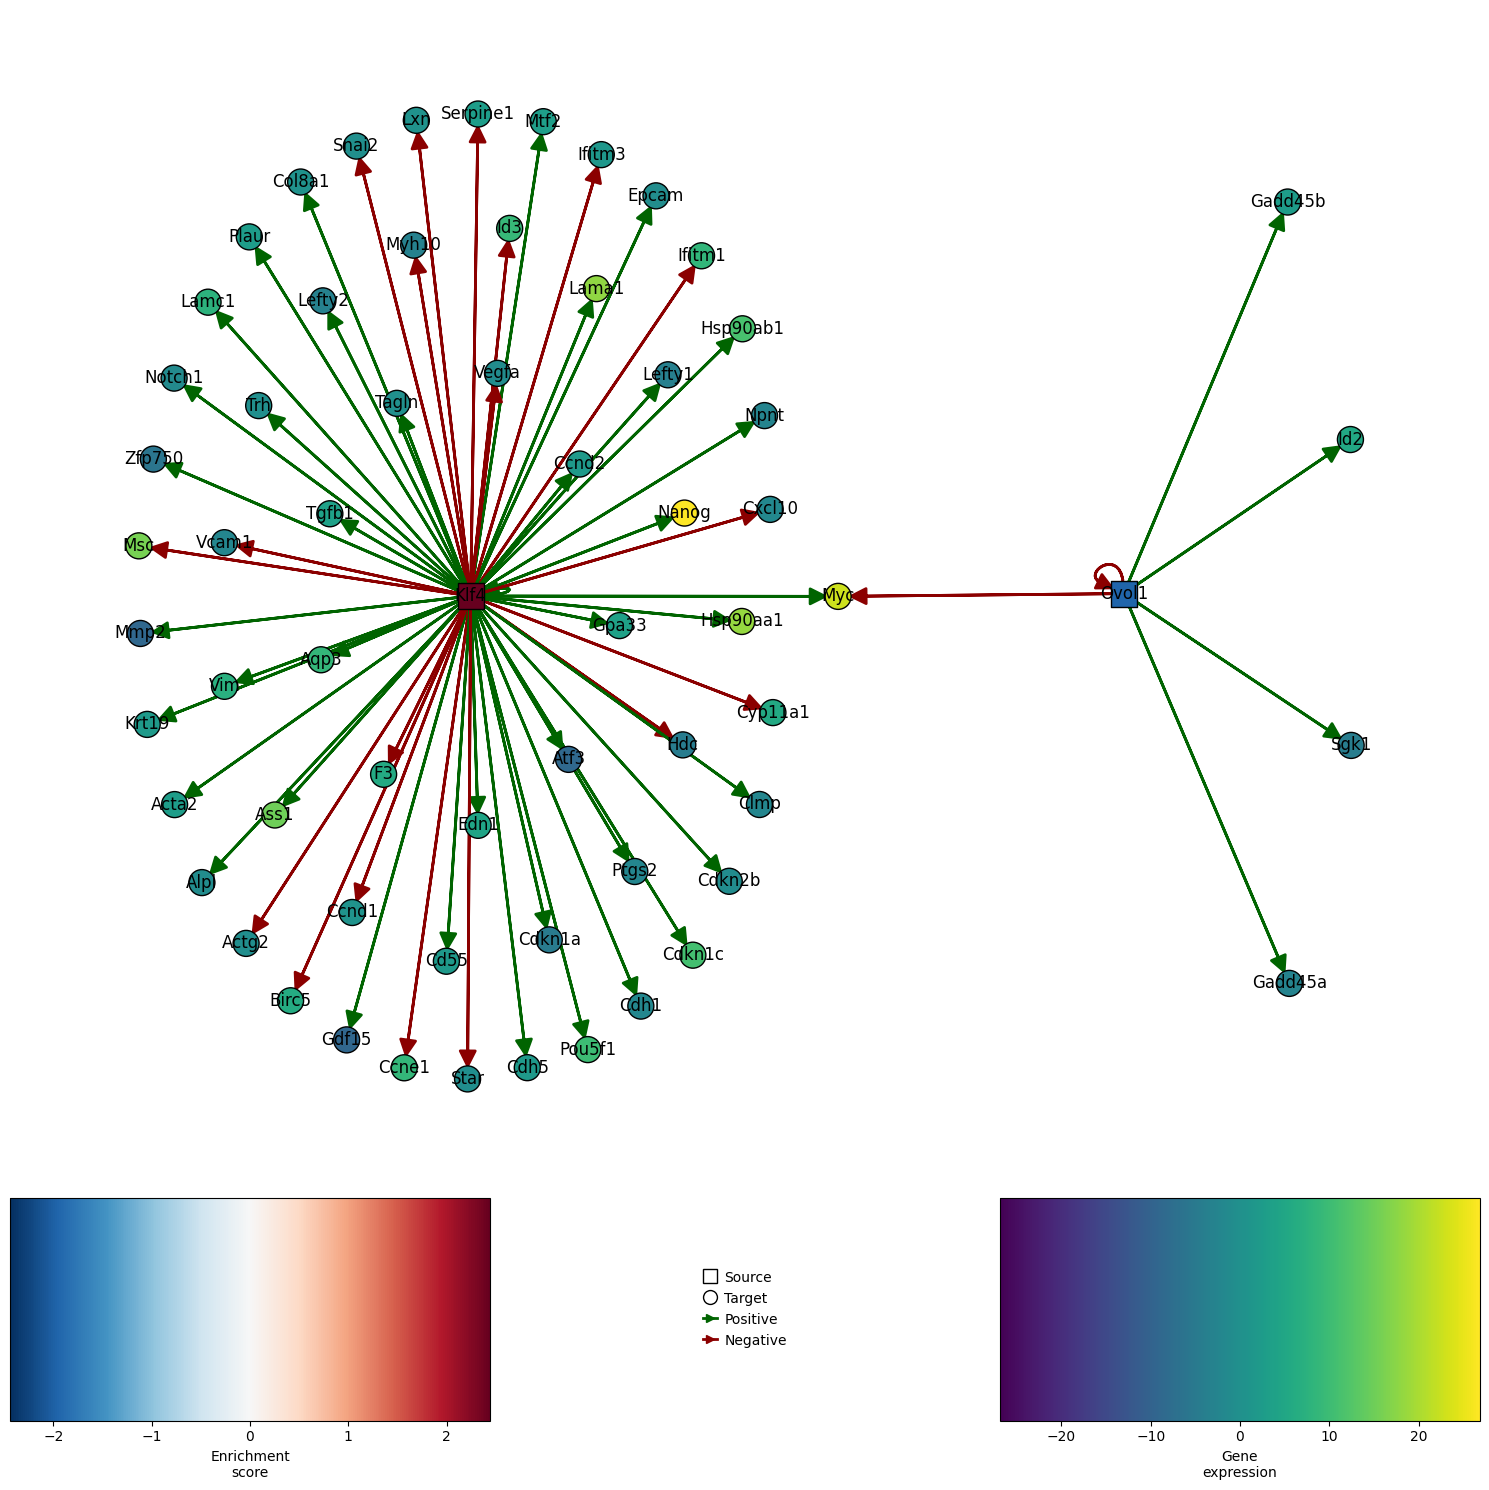

In [94]:
# Plot dead end network for mESCs

data = mesc_de[["stat"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=collectri_df)
activities_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["stat"], "Adjusted p-value": tf_padj.transpose()["stat"]}, index=tf_acts.columns)

decoupler.pl.network(
    net=collectri_df,
    data=data,
    score=tf_acts,
    sources=dead_end_drivers_with_activities + ["Klf4"],
    targets=100,
    figsize=(15, 15),
    vcenter=True,
    by_abs=True,
    size_node=60,
)

# Check if velocity for the dead end drivers correlate with Hic2 expression

In [120]:
cell_markers = gseapy.get_library("PanglaoDB_Augmented_2021", organism="Mouse")
epithelial_markers = numpy.array(pandas.Series(cell_markers["Epithelial Cells"]).str.capitalize())
keratinocyte_markers = numpy.array(pandas.Series(cell_markers["Keratinocytes"]).str.capitalize())
stem_cell_markers = numpy.array(pandas.Series(cell_markers["Pluripotent Stem Cells"]).str.capitalize())

2026-03-04 17:24:13 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-04 17:24:13 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.PanglaoDB_Augmented_2021.gmt, use local file


In [62]:
# Keratinocyte markers among dead end drivers

numpy.intersect1d(keratinocyte_markers, dead_end_drivers)

array(['Anxa8', 'Krt13', 'Krt14', 'Krt17', 'Lad1', 'Lgals7', 'Ovol1',
       'Perp', 'Pkp1', 'S100a14'], dtype=object)

In [95]:
# Epithelial markers among dead end drivers

numpy.intersect1d(epithelial_markers, dead_end_drivers)

array(['Crb3', 'Dgat2', 'Gpx2', 'Krt13', 'Krt14', 'Krt8', 'Lad1', 'Mal2',
       'Misp', 'Ovol1', 'Rab25', 'S100a14'], dtype=object)

In [63]:
# Keratinocyte markers among Hic2 targets

numpy.intersect1d(keratinocyte_markers, hic2_targets)

array(['Anxa8', 'Aqp3', 'B3gnt3', 'Cblc', 'Ccl2', 'Dmkn', 'Dsc3',
       'Duoxa1', 'Ehf', 'Entpd2', 'Evpl', 'Fam83b', 'Fgfbp1', 'Foxn1',
       'Fst', 'Fxyd3', 'Gjb3', 'Gjb4', 'Gjb5', 'Icam1', 'Irf3', 'Itgb4',
       'Klf5', 'Klk8', 'Krt13', 'Krt16', 'Krt80', 'Krt84', 'Krtdap',
       'Lad1', 'Lama5', 'Lamc2', 'Lgals7', 'Mst1r', 'Nectin4', 'Ngfr',
       'Ovol1', 'Perp', 'Pkp1', 'Plec', 'Ppp1r13l', 'S100a14', 'S100a2',
       'Sbsn', 'Scel', 'Sfn', 'Slurp1', 'Sprr1a', 'Syt8', 'Tgm1', 'Tns4',
       'Trim29'], dtype=object)

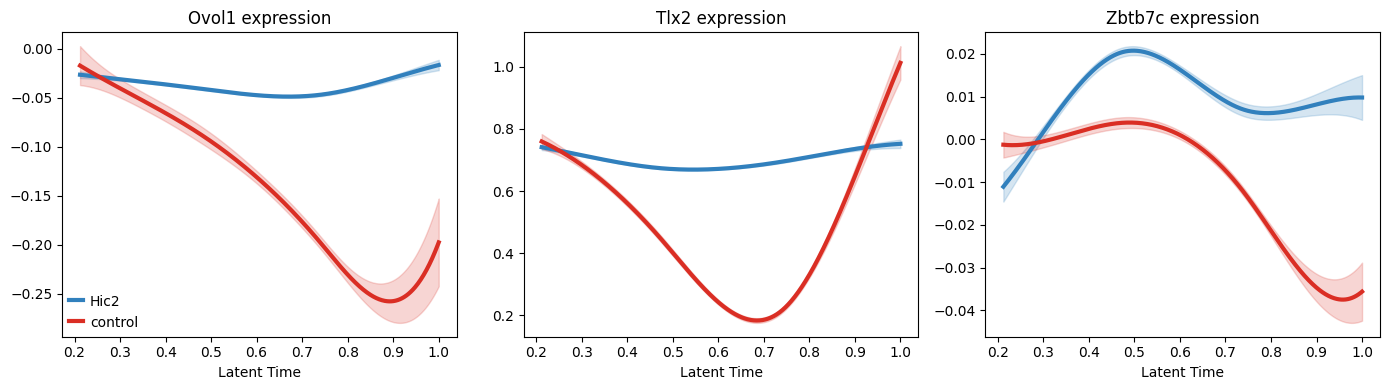

In [ ]:
plot_grouped_gene_trend(adata, genes=de_dead_end_drivers, layer="epithelial_score", groups=["Hic2", "control"])

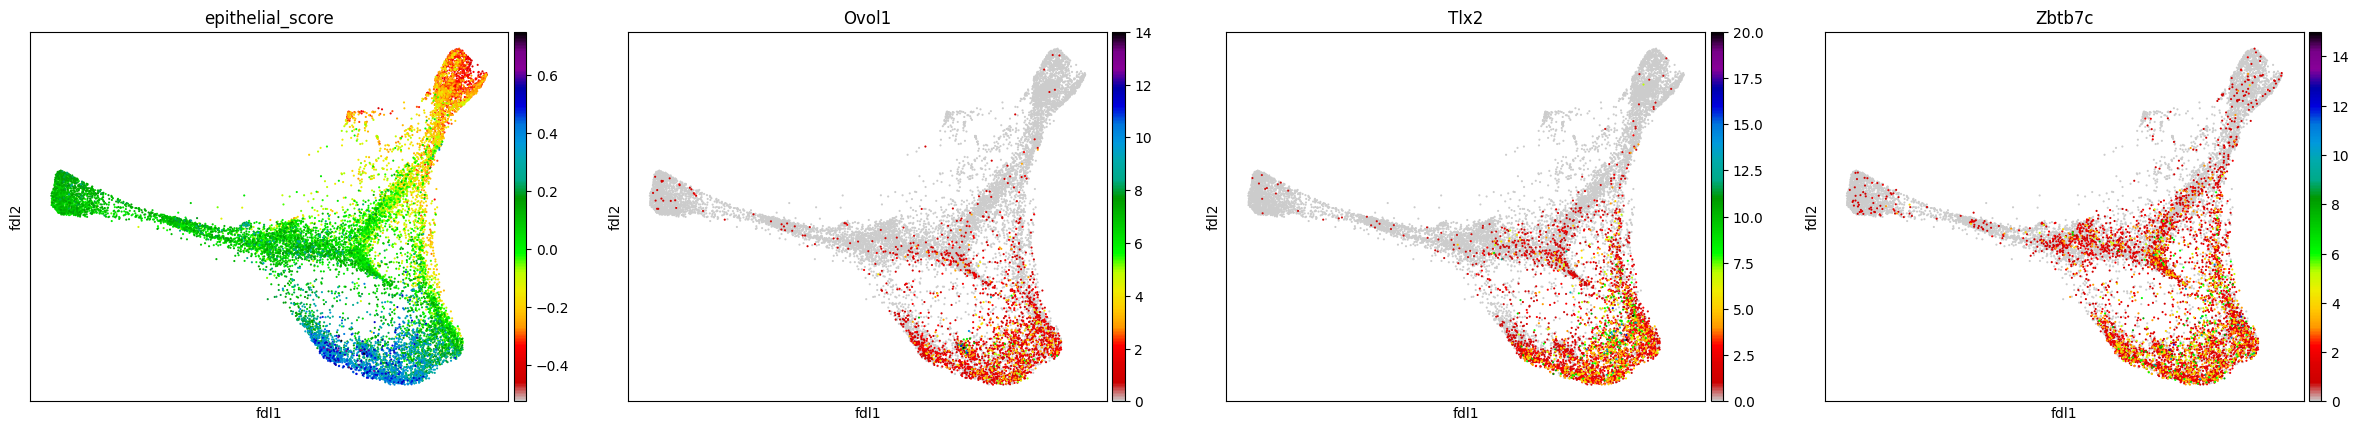

In [133]:
# Plot where epithelial genes are found

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(epithelial_markers, adata.var_names),
    score_name="epithelial_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["epithelial_score"] + de_dead_end_drivers.tolist(),
    cmap="nipy_spectral_r",
    show=True
)

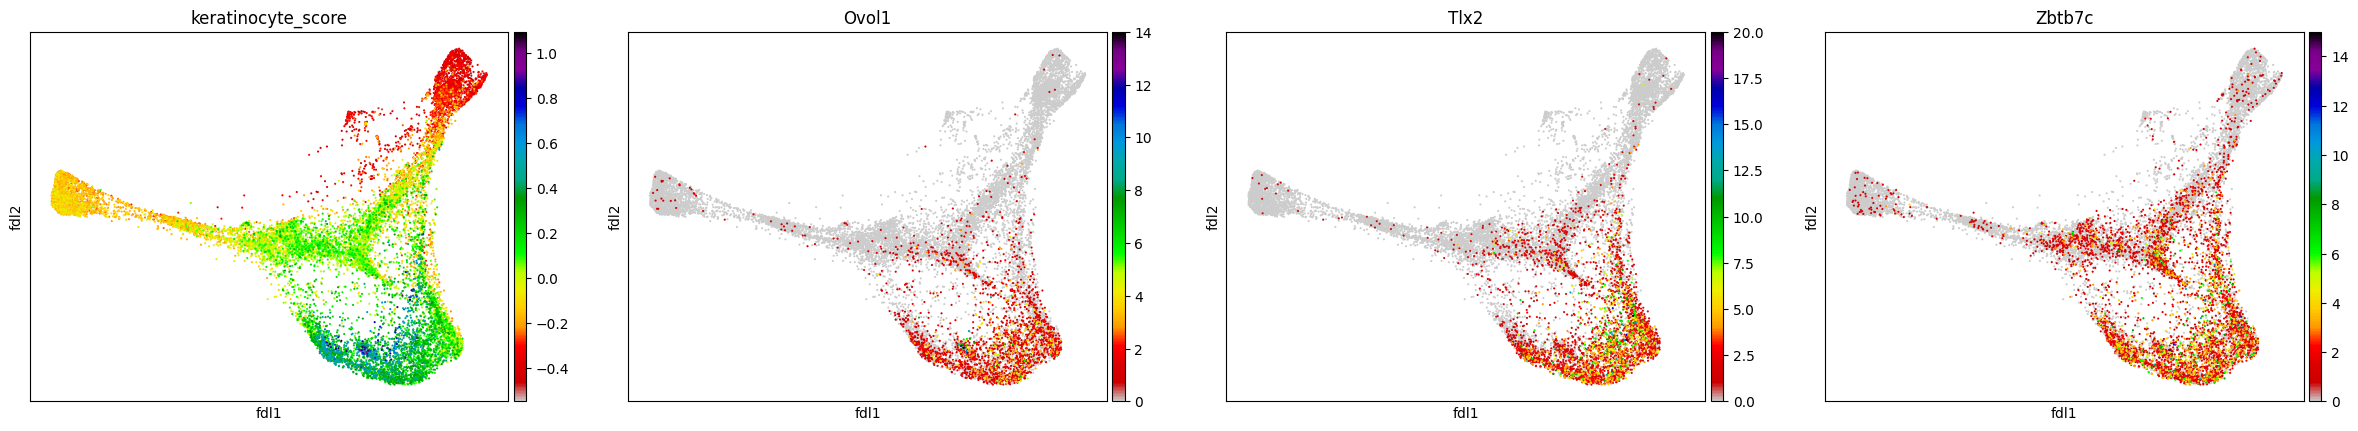

In [132]:
# Plot where keratinocyte genes are found

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(keratinocyte_markers, adata.var_names),
    score_name="keratinocyte_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color=["keratinocyte_score"] + de_dead_end_drivers.tolist(),
    cmap="nipy_spectral_r",
    show=True
)

In [111]:
# Find where apoptosis genes are expressed

go_database = gseapy.get_library("GO_Biological_Process_2025", organism="Mouse")
apoptosis_genes = numpy.array(pandas.Series(go_database["Positive Regulation of Apoptotic Process (GO:0043065)"]).str.capitalize())

2026-03-04 17:20:19 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-04 17:20:19 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.GO_Biological_Process_2025.gmt, use local file
2026-03-04 17:20:19 | [INFO] 0002 gene_sets have been filtered out when max_size=2000 and min_size=0


In [116]:
msig_database = gseapy.get_library("MSigDB_Hallmark_2020")
apoptosis_genes = numpy.array(pandas.Series(msig_database["Apoptosis"]).str.capitalize())

2026-03-04 17:22:36 | [INFO] Downloading and generating Enrichr library gene sets...
2026-03-04 17:22:36 | [INFO] Library is already downloaded in: /home/avesta/m26_losu/.cache/gseapy/Enrichr.MSigDB_Hallmark_2020.gmt, use local file


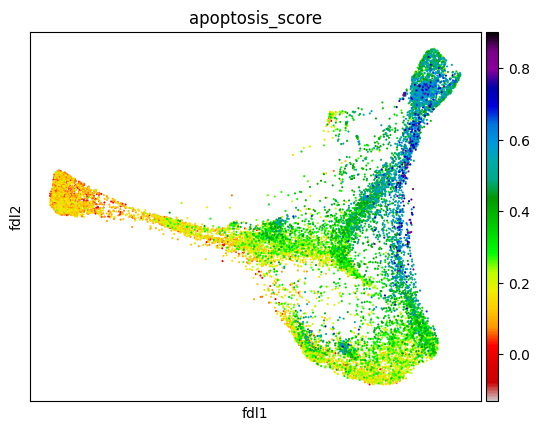

In [ ]:
# Plot where there is apoptosis

scanpy.tl.score_genes(
    adata,
    gene_list=numpy.intersect1d(apoptosis_genes, adata.var_names),
    score_name="apoptosis_score",
    use_raw=False
)

scanpy.pl.embedding(
    adata,
    basis="fdl",
    color="apoptosis_score",
    cmap="nipy_spectral_r",
    show=True
)